In [6]:
# ── Paths derived from Snakefile (make_plots_i / make_plots rules) ────────────
import os, sys
from pathlib import Path

# Same env vars as the Snakefile
GWAK_DIR    = Path(os.environ.get('GWAK_DIR',    '/home/katya.govorkova/gwak2/'))
OUTPUT_DIR  = Path(os.environ.get('GWAK_OUTPUT_DIR', GWAK_DIR / 'gwak/output'))

# Wildcards used in the make_plots rule
CL_CONFIG  = 'ResNet'
FM_CONFIG  = 'NF_from_file_conditioning'
IFOS       = 'HL'

# Paths exactly as make_plots_i constructs them
EMBEDDING_MODEL = OUTPUT_DIR / f'{CL_CONFIG}_{IFOS}/model_JIT.pt'
FM_MODEL        = OUTPUT_DIR / f'{CL_CONFIG}_{FM_CONFIG}_{IFOS}/model_JIT.pt'
DATA_DIR        = OUTPUT_DIR / f'BBC_AnalysisReady_Cat12/{IFOS}/'
CONFIG_PATH     = GWAK_DIR   / f'gwak/train/configs/{CL_CONFIG}.yaml'
BURST_BENCHMARK = GWAK_DIR   / 'gwak/output/embeddings/burst_benchmark_short-0.h5'

sys.path.insert(0, str(GWAK_DIR))
sys.path.insert(0, str(GWAK_DIR / 'gwak/train'))

N_PLOT = 6   # number of samples to visualise

for label, p in [('embedding_model', EMBEDDING_MODEL),
                 ('fm_model',         FM_MODEL),
                 ('data_dir',         DATA_DIR),
                 ('config',           CONFIG_PATH),
                 ('burst_benchmark',  BURST_BENCHMARK)]:
    status = '✓' if Path(p).exists() else '✗ NOT FOUND'
    print(f'{status}  {label}: {p}')

✓  embedding_model: /home/katya.govorkova/gwak2/gwak/output/ResNet_HL/model_JIT.pt
✓  fm_model: /home/katya.govorkova/gwak2/gwak/output/ResNet_NF_from_file_conditioning_HL/model_JIT.pt
✓  data_dir: /home/katya.govorkova/gwak2/gwak/output/BBC_AnalysisReady_Cat12/HL
✓  config: /home/katya.govorkova/gwak2/gwak/train/configs/ResNet.yaml
✓  burst_benchmark: /home/katya.govorkova/gwak2/gwak/output/embeddings/burst_benchmark_short-0.h5


## 1. Load model & config (same as plots.py)

In [7]:
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt

from ml4gw.distributions import PowerLaw
from ml4gw.waveforms import SineGaussian, MultiSineGaussian, IMRPhenomPv2, Gaussian, GenerateString, WhiteNoiseBurst
from gwak.train.dataloader import SignalDataloader
from gwak.data.prior import (
    SineGaussianBBC, MultiSineGaussianBBC, LAL_BBHPrior,
    GaussianBBC, CuspBBC, KinkBBC, KinkkinkBBC, WhiteNoiseBurstBBC
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

embed_model = torch.jit.load(EMBEDDING_MODEL, map_location=device)
embed_model.eval()
print('Model loaded')

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

cfg              = config['data']['init_args']
sample_rate      = cfg['sample_rate']
kernel_length    = cfg['kernel_length']
psd_length       = cfg['psd_length']
fduration        = cfg['fduration']
fftlength        = cfg['fftlength']
num_workers      = cfg['num_workers']
data_saving_file = cfg.get('data_saving_file', None)
duration         = fduration + kernel_length
batch_size       = 32   # small for notebook

print(f'sample_rate={sample_rate}, kernel_length={kernel_length}s, psd_length={psd_length}s')

device: cuda
Model loaded
sample_rate=4096, kernel_length=1.0s, psd_length=64s


## 2. Set up SignalDataloader (same as plots.py)

In [8]:
signal_classes = [
    'MultiSineGaussian', 'SineGaussian', 'BBH', 'Gaussian',
    'Cusp', 'Kink', 'KinkKink', 'WhiteNoiseBurst',
    'CCSN', 'Background', 'Glitch',
]

priors = [
    MultiSineGaussianBBC(), SineGaussianBBC(), LAL_BBHPrior(), GaussianBBC(),
    CuspBBC(), KinkBBC(), KinkkinkBBC(), WhiteNoiseBurstBBC(),
    None, None, None,
]

waveforms = [
    MultiSineGaussian(sample_rate=sample_rate, duration=duration),
    SineGaussian(sample_rate=sample_rate, duration=duration),
    IMRPhenomPv2(),
    Gaussian(sample_rate=sample_rate, duration=duration),
    GenerateString(sample_rate=sample_rate),
    GenerateString(sample_rate=sample_rate),
    GenerateString(sample_rate=sample_rate),
    WhiteNoiseBurst(sample_rate=sample_rate, duration=duration),
    None, None, None,
]

extra_kwargs = [
    None, None, {'ringdown_duration': 0.9}, None,
    None, None, None, None,
    None, None, None,
]

loader = SignalDataloader(
    signal_classes, priors, waveforms, extra_kwargs,
    data_dir=DATA_DIR,
    sample_rate=sample_rate,
    kernel_length=kernel_length,
    psd_length=psd_length,
    fduration=fduration,
    fftlength=fftlength,
    batch_size=batch_size,
    batches_per_epoch=100,
    num_workers=num_workers,
    data_saving_file=data_saving_file,
    ifos=IFOS,
    snr_prior=PowerLaw(index=3, minimum=4, maximum=30),
)

print('Dataloader ready')

ifos are ['H1', 'L1']
data dir is /home/katya.govorkova/gwak2/gwak/output/BBC_AnalysisReady_Cat12/HL
Dataloader ready


## 5. Compute embeddings on O4 burst short (from scripts/compute_embeddings.py)

In [9]:
import h5py
from tqdm import tqdm
from ml4gw.transforms import SpectralDensity, Whiten
from gwak.train.dataloader import TorchBandpassFIR

O4_DIR   = OUTPUT_DIR / f'O4_MDC_short-0/{IFOS}/'
out_path = OUTPUT_DIR / 'embeddings/o4_short-0_embeddings_with_injections.h5'

kernel_samples    = int(kernel_length * sample_rate)
psd_samples       = int(psd_length * sample_rate)
fduration_samples = int(fduration * sample_rate)
batch_size_emb    = 32

bandpass         = TorchBandpassFIR(lowcut=30, highcut=2047, sample_rate=sample_rate).to(device)
whitener         = Whiten(fduration, sample_rate, highpass=30).to(device)
spectral_density = SpectralDensity(sample_rate, fftlength, average='median').to(device)

def parse_gps_from_filename(h5_path):
    parts = Path(h5_path).stem.split('-')
    return float(parts[-2])

def embed_file(h5_path, model, bandpass, whitener, spectral_density, device):
    with h5py.File(h5_path, 'r') as f:
        ifos_in_file = [k for k in ['H1', 'L1', 'V1'] if k in f]
        strain    = np.stack([f[ifo][:] for ifo in ifos_in_file], axis=0)
        gps_start = float(f[ifos_in_file[0]].attrs.get('start_time', 0.0))
        if gps_start == 0.0:
            gps_start = parse_gps_from_filename(h5_path)

    total       = strain.shape[1]
    first_start = psd_samples
    available   = total - psd_samples - fduration_samples
    n_segments  = available // kernel_samples

    segments, psd_segs, seg_gps = [], [], []
    for i in range(n_segments):
        start = first_start + i * kernel_samples
        end   = start + kernel_samples + fduration_samples
        if end > total:
            break
        segments.append(strain[:, start:end])
        psd_segs.append(strain[:, start - psd_samples:start])
        seg_gps.append(gps_start + start / sample_rate)

    if not segments:
        return np.array([]), np.array([])

    all_emb = []
    with torch.no_grad():
        for b in range(0, len(segments), batch_size_emb):
            seg_t = torch.tensor(np.stack(segments[b:b+batch_size_emb]), dtype=torch.float32, device=device)
            psd_t = torch.tensor(np.stack(psd_segs[b:b+batch_size_emb]),  dtype=torch.float32, device=device)
            seg_bp   = bandpass(seg_t)
            psds     = spectral_density(psd_t.double())
            whitened = whitener(seg_bp.double(), psds.double()).float()
            whitened = whitened[:, :, :kernel_samples]
            stds     = whitened.std(dim=-1, keepdim=True).clamp(min=1e-8)
            whitened = whitened / stds
            emb = model(whitened)
            all_emb.append(emb.cpu().numpy())

    return np.concatenate(all_emb, axis=0), np.array(seg_gps)

o4_files = sorted(O4_DIR.glob('*.h5'))
print(f'Found {len(o4_files)} O4 files in {O4_DIR}')

o4_embeddings_list, o4_gps_list = [], []
for f in tqdm(o4_files, desc='O4 files'):
    emb, gps = embed_file(f, embed_model, bandpass, whitener, spectral_density, device)
    if len(emb):
        o4_embeddings_list.append(emb)
        o4_gps_list.append(gps)

o4_emb = np.concatenate(o4_embeddings_list, axis=0)
o4_gps = np.concatenate(o4_gps_list, axis=0)
print(f'O4 embeddings shape: {o4_emb.shape}  GPS range: {o4_gps[0]:.1f} – {o4_gps[-1]:.1f}')

Found 101 O4 files in /home/katya.govorkova/gwak2/gwak/output/O4_MDC_short-0/HL


O4 files:   0%|                                                                                              | 0/101 [00:00<?, ?it/s]/home/katya.govorkova/gwak2/gwak/train/dataloader.py:138: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:1036.)
  return torch.nn.functional.conv1d(x, weight, groups=C, padding="same")
O4 files: 100%|██████████████████████████████████████████████████████████████████████████████████| 101/101 [1:39:12<00:00, 58.94s/it]

O4 embeddings shape: (1147998, 6)  GPS range: 1401696385.0 – 1403908317.0


## 5b. Read injection metadata from burst benchmark & match to segment indices

In [10]:
# ── Read injections from burst benchmark file ────────────────────────────────
inj_type  = []
inj_gps   = []

with h5py.File(BURST_BENCHMARK, 'r') as h5_file:
    for key in list(h5_file.keys()):
        sig_type = h5_file[key].attrs['type']
        params   = h5_file[key]['PARAMETERS'][:]
        times    = params['time'][:]
        for t in times:
            inj_type.append(sig_type)
            inj_gps.append(float(t))

inj_type = np.array(inj_type)
inj_gps  = np.array(inj_gps)
print(f'Total injections in benchmark: {len(inj_gps)}')
print('Signal types:', np.unique(inj_type))

# ── Match each injection GPS time to embedding indices ───────────────────────
#
# Mark all segments whose window overlaps with [t_inj - 1, t_inj + 1].
# Segment i covers [o4_gps[i], o4_gps[i] + kernel_length), so it overlaps when:
#   o4_gps[i] < t_inj + 1  AND  o4_gps[i] + kernel_length > t_inj - 1
#
# Injections in the first psd_length seconds of any file are discarded.
#
inj_window = 1.0  # seconds on each side of the injection

n_seg        = len(o4_emb)
seg_inj_type = np.full(n_seg, '', dtype=object)
seg_has_inj  = np.zeros(n_seg, dtype=bool)

n_matched = 0
for j, t in enumerate(inj_gps):
    candidates = np.where(
        (o4_gps < t + inj_window) &
        (o4_gps + kernel_length > t - inj_window)
    )[0]
    if len(candidates):
        n_matched += 1
    for idx in candidates:
        seg_inj_type[idx] = inj_type[j]
        seg_has_inj[idx]  = True

print(f'Matched:   {n_matched} / {len(inj_gps)} injections')
print(f'Discarded: {len(inj_gps) - n_matched} injections (outside any embedding window)')
print(f'Embedding segments marked as signal: {seg_has_inj.sum()} / {n_seg}')

Total injections in benchmark: 23732
Signal types: ['CSC' 'CSK' 'CSKK' 'GA' 'SG' 'WAVE' 'WNB']
Matched:   11246 / 23732 injections
Discarded: 12486 injections (outside any embedding window)
Embedding segments marked as signal: 33725 / 1147998


In [11]:
out_path.parent.mkdir(parents=True, exist_ok=True)
with h5py.File(out_path, 'w') as f:
    f.create_dataset('embeddings',    data=o4_emb,                      compression='gzip')
    f.create_dataset('gps_times',     data=o4_gps,                      compression='gzip')
    f.create_dataset('has_injection', data=seg_has_inj.astype(np.int8), compression='gzip')
    dt = h5py.special_dtype(vlen=str)
    ds = f.create_dataset('inj_type', shape=(n_seg,), dtype=dt)
    ds[:] = seg_inj_type.tolist()

print(f'Saved to {out_path}')
print(f'  embeddings:    {o4_emb.shape}')
print(f'  injected segs: {seg_has_inj.sum()}  ({seg_has_inj.mean()*100:.1f}%)')

Saved to /home/katya.govorkova/gwak2/gwak/output/embeddings/o4_short-0_embeddings_with_injections.h5
  embeddings:    (1147998, 6)
  injected segs: 33725  (2.9%)


In [12]:
# indices of all True values
true_idx = np.where(seg_has_inj)[0]

# find where consecutive True indices are not adjacent (gap > 1) → cluster boundaries
breaks = np.where(np.diff(true_idx) > 1)[0]

# first index of each cluster
cluster_starts = true_idx[np.concatenate([[0], breaks + 1])]

# distance between consecutive cluster starts
distances = np.diff(cluster_starts)
print('Distances between injection clusters:', distances)
print('Min distance:', distances.min())
print('Max distance:', distances.max())
print('Mean distance:', distances.mean())

Distances between injection clusters: [ 96 103 105 ... 108  97  95]
Min distance: 15
Max distance: 186
Mean distance: 102.08039128501557


In [27]:
n_background = 90  # background embeddings preceding each injection cluster
n_injection  = 3   # injection embeddings (±1 sec window)
n_window     = n_background + n_injection

# first cluster: need at least n_background embeddings before it
valid_mask = np.ones(len(cluster_starts), dtype=bool)
if cluster_starts[0] < n_background:
  valid_mask[0] = False

# all other clusters: distance to previous must be >= n_background
valid_mask[1:] = distances >= n_background

valid_starts = cluster_starts[valid_mask]
print(f'Valid clusters: {valid_mask.sum()} / {len(cluster_starts)} '
    f'({(~valid_mask).sum()} dropped due to distance < {n_background})')

# build [N, n_window, 6] array: n_background background + n_injection injection embeddings
windows = np.stack([o4_emb[s - n_background : s + n_injection] for s in valid_starts], axis=0)
labels  = np.stack([seg_has_inj[s - n_background : s + n_injection] for s in valid_starts], axis=0)

print(f'windows shape: {windows.shape}')   # [N, n_window, 6]
print(f'labels shape:  {labels.shape}')    # [N, n_window]

Valid clusters: 11207 / 11246 (39 dropped due to distance < 90)
windows shape: (11207, 93, 6)
labels shape:  (11207, 93)


In [30]:
save_path = OUTPUT_DIR / f'embeddings/o4_windows_bg{n_background}_inj{n_injection}.npy'
np.save(save_path, windows)
print(f'Saved to {save_path}  shape={windows.shape}')

Saved to /home/katya.govorkova/gwak2/gwak/output/embeddings/o4_windows_bg90_inj3.npy  shape=(11207, 93, 6)


In [13]:
# Collect background-only embeddings from multiple batches
all_background = ['Background', 'Glitch']
bg_labels_set  = set(i + 1 for i, c in enumerate(signal_classes) if c in all_background)

bkg_emb_list = []
n_batches_bkg = 20   # collect ~20 * batch_size background windows

test_loader = loader.test_dataloader()
test_iter   = iter(test_loader)

for _ in tqdm(range(n_batches_bkg), desc='background batches'):
    try:
        clean_batch, glitch_batch = next(test_iter)
    except StopIteration:
        break
    clean_batch  = clean_batch.to(device)
    glitch_batch = glitch_batch.to(device)

    processed, labels, snrs, hrss = loader.on_after_batch_transfer(
        [clean_batch, glitch_batch], None, local_test=True
    )

    mask = torch.tensor([l.item() in bg_labels_set for l in labels], device=device)
    if mask.sum() == 0:
        continue

    with torch.no_grad():
        emb = embed_model(processed[mask])
    bkg_emb_list.append(emb.cpu().numpy())

bkg_emb = np.concatenate(bkg_emb_list, axis=0)
print(f'Background embeddings shape: {bkg_emb.shape}')

/home/katya.govorkova/miniconda3/envs/gwak/lib/python3.11/site-packages/ml4gw/dataloading/hdf5_dataset.py:169: ContiguousHdf5Warning: /home/katya.govorkova/gwak2/gwak/output/BBC_AnalysisReady_Cat12/HL/background-1403643004-2013.h5 stored contiguously – slower I/O
  warnings.warn(f"{fname} stored contiguously – slower I/O", ContiguousHdf5Warning)
/home/katya.govorkova/miniconda3/envs/gwak/lib/python3.11/site-packages/ml4gw/dataloading/hdf5_dataset.py:169: ContiguousHdf5Warning: /home/katya.govorkova/gwak2/gwak/output/BBC_AnalysisReady_Cat12/HL/background-1403645022-928.h5 stored contiguously – slower I/O
  warnings.warn(f"{fname} stored contiguously – slower I/O", ContiguousHdf5Warning)
/home/katya.govorkova/miniconda3/envs/gwak/lib/python3.11/site-packages/ml4gw/dataloading/hdf5_dataset.py:169: ContiguousHdf5Warning: /home/katya.govorkova/gwak2/gwak/output/BBC_AnalysisReady_Cat12/HL/background-1403645955-1083.h5 stored contiguously – slower I/O
  warnings.warn(f"{fname} stored contiguo

Background embeddings shape: (80, 6)


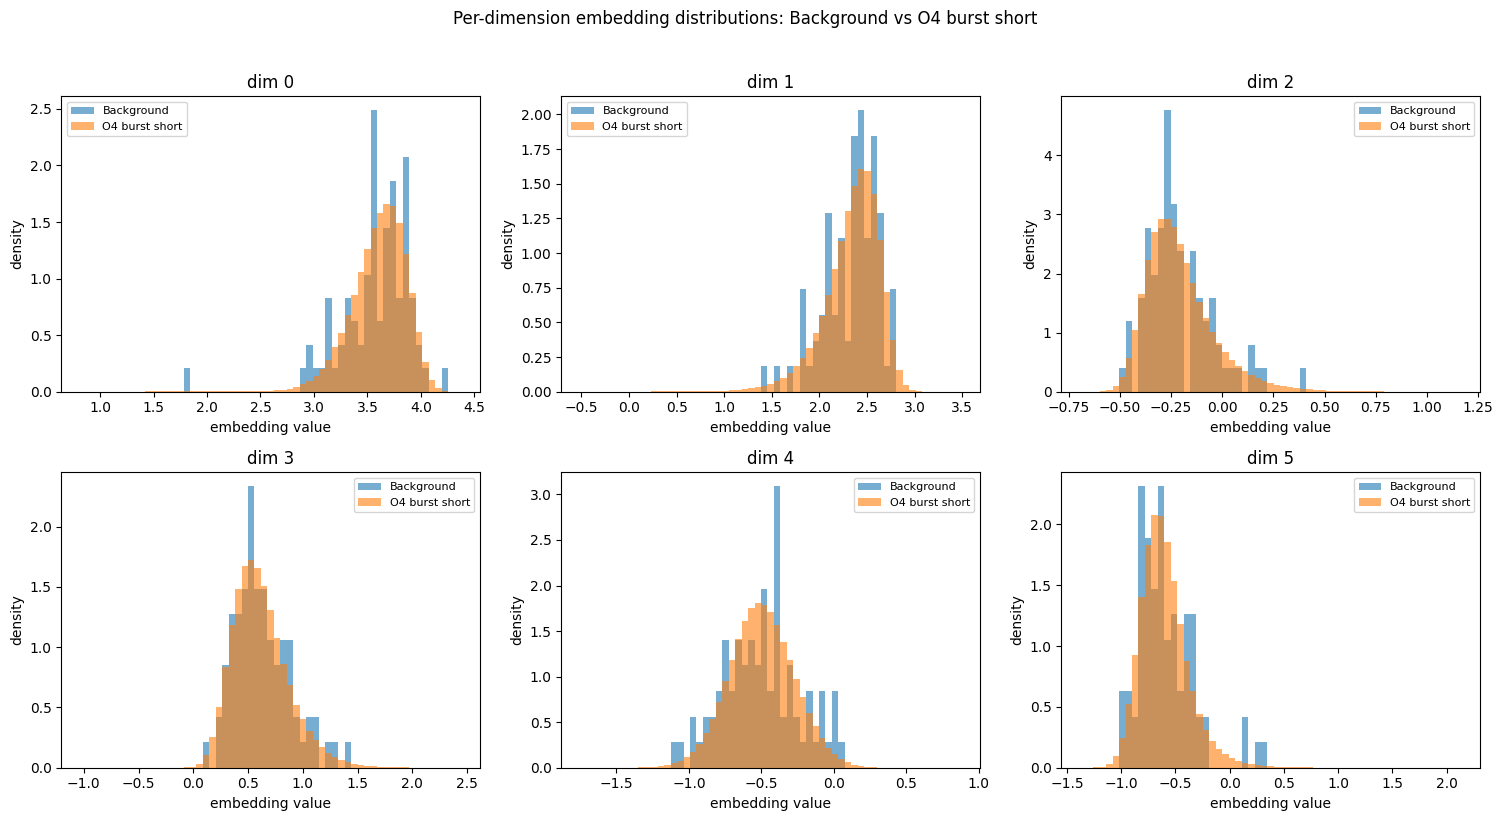

In [14]:
n_dims = bkg_emb.shape[1]
ncols  = 3
nrows  = (n_dims + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for d in range(n_dims):
    ax = axes[d]
    lo = min(bkg_emb[:, d].min(), o4_emb[:, d].min())
    hi = max(bkg_emb[:, d].max(), o4_emb[:, d].max())
    bins = np.linspace(lo, hi, 60)

    ax.hist(bkg_emb[:, d], bins=bins, density=True, alpha=0.6, label='Background')
    ax.hist(o4_emb[:, d],  bins=bins, density=True, alpha=0.6, label='O4 burst short')
    ax.set_title(f'dim {d}')
    ax.set_xlabel('embedding value')
    ax.set_ylabel('density')
    ax.legend(fontsize=8)

# Hide unused axes
for d in range(n_dims, len(axes)):
    axes[d].set_visible(False)

plt.suptitle('Per-dimension embedding distributions: Background vs O4 burst short', y=1.02)
plt.tight_layout()
plt.show()